# Applied Math 10: Computing for Science and Engineering

## HW-10 : Second-order Ordinary Differential Equations (ODEs)

**Fall 2020**<br/>
<br>
Handed out: Thursday, Nov. 12, 2020

Due: 11.59 am; Thursday, Nov. 19, 2020

___________________________________________________________________________________________________________________________

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## Problem 1
 
Consider the simplified motion of an object of mass $m$ as it travels toward Earth under the attraction of the gravitational force, described by the differential equation

$$\frac {d^2 \bf{r}}{dt^2} = - \frac{G \ M_E \ \bf {r}}{r^3}$$

where $\bf {r} $ is the object's radial distance vector from the center of the Earth ($r$ is its magnitude), $M_E$ is the mass of the Earth, and $G$ is the universal gravitational constant.

This equation can be recast as a system of two coupled equations

$$\frac {d^2 x}{dt^2} = - \frac{G \ M_E \ x}{(x^2 + y^2)^{3/2}}$$

and

$$\frac {d^2 y}{dt^2} = - \frac{G \ M_E \ y}{(x^2 + y^2)^{3/2}}$$

where $x(t)$ and $y(t)$ are the object's positions in the cartesian $x-$ and $y-$ axes.

Solve the differential equation (by using the methods and functions developed in Lecture and Lab) to find the approximate solutions $x(t)$ and $y(t)$, and plot them ($x(t)$, $y(t)$). Consider scaled units with $0 \le t \le 24$, $G \ M_E = 200$, and place the object at distance $x(0) = 8$, with $y(0) = 0$, initial velocity in the x-direction $v_x(0)=0$, and explore two cases for the initial velocity in the y-direction: a) $v_y(0) = +5$, and b) $v_y(0) = +10$. Comment on your results.


PART A


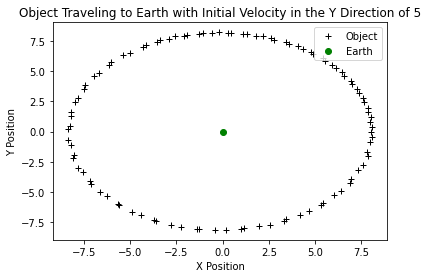

PART B


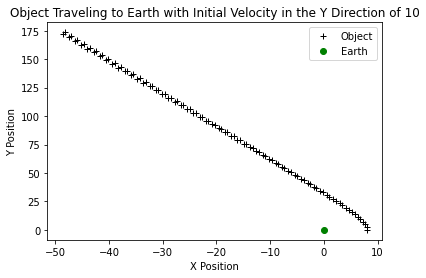


It appears that when the intial velocity in the Y direction is 5, the object orbits ellipitically. However, when the inital velocity in the Y direction is 10, the object has a much more linear trajectory, as opposed to the circular trajectory in Part A. However, the trajectory does appear to be curve slightly as the object gets closer to Earth, so it would be interesting to see if we see orbital behavior as time goes past t = 10.


In [7]:
# Define interval and information given 
Nt=100
tmin=0
tmax=24
t = np.linspace(tmin,tmax,Nt)
dt = t[1] - t[0]
dt2 = 2.0*dt 
GME = 200

print("PART A")
# Initialize 
ufx=np.zeros(Nt)
ufy=np.zeros(Nt)
udx=np.zeros(Nt)
udy=np.zeros(Nt)
gx=np.zeros(Nt)
gy=np.zeros(Nt)

# Initial Conditions
ufx[0]=8.0
udx[0]=0.0
ufy[0]=0.0
udy[0]=5.0

# Define Diff Eqs
gx[0]= -(GME*ufx[0])/ (ufx[0]**2+ufy[0]**2)**(3/2) # x second order diff eq 
gy[0]= -(GME*ufy[0])/ (ufx[0]**2+ufy[0]**2)**(3/2) # y second order diff eq

# Define step
ufx[1]=ufx[0]+udx[0]*dt
udx[1]=udx[0]+gx[0]*dt
ufy[1]=ufy[0]+udy[0]*dt
udy[1]=udy[0]+gy[0]*dt


# For loop to evaluate at different values of time
for n in range(1,Nt-1):
    gx[n]= -(GME*ufx[n])/ (ufx[n]**2+ufy[n]**2)**(3/2)
    gy[n]= -(GME*ufy[n])/ (ufx[n]**2+ufy[n]**2)**(3/2)
    udx[n+1]=udx[n-1]+gx[n]*dt2
    ufx[n+1]=ufx[n-1]+udx[n]*dt2
    udy[n+1]=udy[n-1]+gy[n]*dt2
    ufy[n+1]=ufy[n-1]+udy[n]*dt2
    
# Plot
plt.plot(ufx,ufy,'k+',label = "Object")
plt.plot(0,0,'go',label = "Earth")
plt.title("Object Traveling to Earth with Initial Velocity in the Y Direction of 5")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.show()

print("PART B") # I just chose to copy and paste rather than loop, so most of this is just pasted from above
# Initialize
ufx=np.zeros(Nt)
ufy=np.zeros(Nt)
udx=np.zeros(Nt)
udy=np.zeros(Nt)
gx=np.zeros(Nt)
gy=np.zeros(Nt)

# Modify Initial Conditions
ufx[0]=8.0
udx[0]=0.0
ufy[0]=0.0
udy[0]=10.0

gx[0]= -(GME*ufx[0])/ (ufx[0]**2+ufy[0]**2)**(3/2) # x second order diff eq 
gy[0]= -(GME*ufy[0])/ (ufx[0]**2+ufy[0]**2)**(3/2) # y second order diff eq

ufx[1]=ufx[0]+udx[0]*dt
udx[1]=udx[0]+gx[0]*dt
ufy[1]=ufy[0]+udy[0]*dt
udy[1]=udy[0]+gy[0]*dt

# For loop to evaluate at different values of time
for n in range(1,Nt-1):
    gx[n]= -(GME*ufx[n])/ (ufx[n]**2+ufy[n]**2)**(3/2)
    gy[n]= -(GME*ufy[n])/ (ufx[n]**2+ufy[n]**2)**(3/2)
    udx[n+1]=udx[n-1]+gx[n]*dt2
    ufx[n+1]=ufx[n-1]+udx[n]*dt2
    udy[n+1]=udy[n-1]+gy[n]*dt2
    ufy[n+1]=ufy[n-1]+udy[n]*dt2
    
# Plot 
plt.plot(ufx,ufy,'k+',label = "Object")
plt.plot(0,0,'go',label = "Earth")
plt.title("Object Traveling to Earth with Initial Velocity in the Y Direction of 10")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.show()
print()
print("It appears that when the intial velocity in the Y direction is 5, the object orbits ellipitically. However, when the inital velocity in the Y direction is 10, the object has a much more linear trajectory, as opposed to the circular trajectory in Part A. However, the trajectory does appear to be curve slightly as the object gets closer to Earth, so it would be interesting to see if we see orbital behavior as time goes past t = 10.")



## Problem 2

Consider a system executing, simultaneously, two independent motions in the x- and in the y- directions, described by the second order ODEs:

$$\frac {d^2 x}{dt^2} = - x $$

$$\frac {d^2 y}{dt^2} = - \omega ^2 y + \alpha$$

In a Wikipedia video (https://en.wikipedia.org/wiki/Harmonograph) you can see the motion of such a system, the "harmonograph", in which a (stationary) pen produces drawings in the moving drawing board underneath it; the board performs independent motions (described by equations of the type shown above) along the x- and y- directions.

Solve the ODEs to obtain the $x(t)$ and the $y(t)$ solutions in the time interval $-10 \le t \le 10$, with initial conditions $x(0) = y(0) = 0$ and $x'(0) = y'(0) = -1$. Plot $x(t)$ versus $y(t)$.
Consider the following combinations of parameters: 

a) $\omega = 0.5$, $\alpha = 0.25$

b) $\omega = 0.5$, $\alpha = 0.5$

c) $\omega = 1.0$, $\alpha = 0.5$

d) $\omega = 1.25$, $\alpha = 10$

Hint: You expect to create plots encountered in a previous homework problem. What is the name of these plots?   

PART A


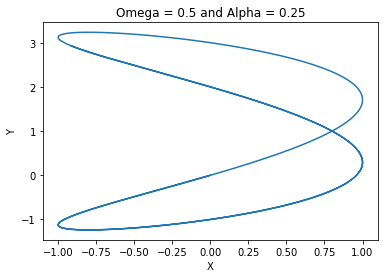

PART B


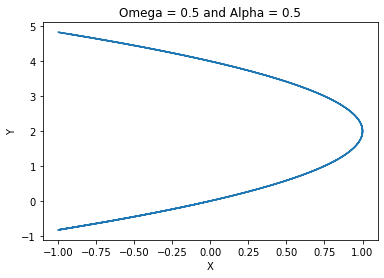

PART C


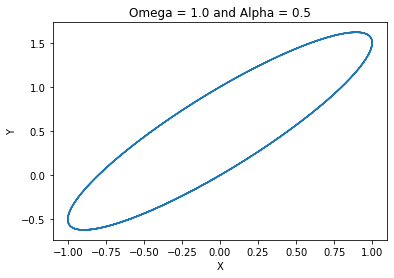

PART D


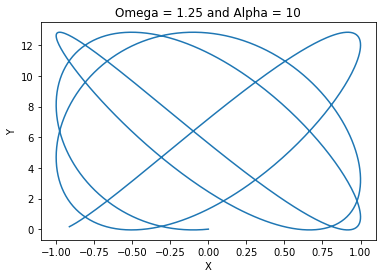

These are Lissajous figures, named after French physicist Jules Antoine Lissajous!


In [8]:
# Define Interval 
Nt = 1000
tmin = -10 
tmax= 10 
t = np.linspace(tmin,tmax,Nt)

# Define Initial Conditions
uf0 = 0
vf0 = -1

# Define Runge Kutta Method 
def ode2_rk2(Nx, xmin, xmax, uf0, vf0):
    #Diff eqns of form: 
    #                 d(uf)/dx=ff(x,uf,vf)
    #                 d(vf)/dx=gf(x,uf,vf)
    #Nx: Number of points to be used for integration
    #xmin, xmax: Initial and final values of the independent variable (x)
    #uf0, vf0: Initial (boundary) values of the dependent variables at x=xmin
     
    x = np.linspace(xmin, xmax, Nx)
    dx = x[1] - x[0] # dx = h 
    
    uf = np.zeros(Nx) # uf = u 
    vf = np.zeros(Nx) # vf = v 
    
    #Initial conditions on u and v
    uf[0] = uf0
    vf[0] = vf0
    
    #We define two variables that minimize repetitive computations (such as multiplying or dividing dx by 2)
    #You can use these below while coding
    
    dxovr4 = dx / 4.0
    dxovr2 = dx / 2.0

    for n in range(Nx - 1):
        #We need to suppy the functions ff(x,uf,vf) and gf(x,uf,vf)
        
        #Formulae can be coded as:
        kn1 = ff(x[n], uf[n], vf[n]) 
        ln1 = gf(x[n], uf[n], vf[n])

        kn2 = ff(x[n] + dxovr2, uf[n] + dxovr2 * kn1, vf[n]+dxovr2 * ln1)
        ln2 = gf(x[n] + dxovr2, uf[n] + dxovr2 * kn1, vf[n]+dxovr2 * ln1)

        ''' Code remaining formulae'''
        #--------------------------------------------------------------------
        kn3 = ff(x[n] + dx, uf[n] + dx * kn2, vf[n]+dx * ln2)
        ln3 = gf(x[n] + dx, uf[n] + dx * kn2, vf[n]+dx * ln2)

             
        uf[n+1] = uf[n] + dxovr4 * (kn1 + 2.0 * kn2 + kn3)
        vf[n+1] = vf[n] + dxovr4 * (ln1 + 2.0 * ln2 + ln3)
        #-------------------------------------------------------------------
    return uf

print("PART A")

#Define gf and ff
def gf(t,uf,vf):
    return -uf

def ff(t,uf,vf):
    return vf 

# get array for x 
x = ode2_rk2(Nt, tmin, tmax, uf0, vf0)

omega = 0.5 #given 
alpha = 0.25 #given

def gf(t,uf,vf):
    return -omega**2*uf+alpha

def ff(t,uf,vf):
    return vf 
y = ode2_rk2(Nt, tmin, tmax, uf0, vf0)
# plotting 
plt.plot(x,y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Omega = 0.5 and Alpha = 0.25")
plt.show()
print("PART B")
# redefine alpha and omega with the correct values, only need to re-evaluate y because x stays the same
omega = 0.5 #given
alpha = 0.5 #given
def gf(t,uf,vf):
    return -omega**2*uf+alpha

def ff(t,uf,vf):
    return vf 
y = ode2_rk2(Nt, tmin, tmax, uf0, vf0)
# plotting 
plt.plot(x,y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Omega = 0.5 and Alpha = 0.5")
plt.show()
print("PART C")
omega = 1.0 #given
alpha = 0.5 #given
def gf(t,uf,vf):
    return -omega**2*uf+alpha

def ff(t,uf,vf):
    return vf 
y = ode2_rk2(Nt, tmin, tmax, uf0, vf0)
# plotting 
plt.plot(x,y) 
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Omega = 1.0 and Alpha = 0.5")
plt.show()
print("PART D")
omega = 1.25 #given 
alpha = 10 #given 
def gf(t,uf,vf):
    return -omega**2*uf+alpha

def ff(t,uf,vf):
    return vf 
y = ode2_rk2(Nt, tmin, tmax, uf0, vf0)
# plotting 
plt.plot(x,y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Omega = 1.25 and Alpha = 10")
plt.show()
print("These are Lissajous figures, named after French physicist Jules Antoine Lissajous!")

## Problem 3

In this problem you will study the motion of a harmonic oscillator (e.g., mass $m$ attached to a spring) but with friction opposing the motion. The equation of motion is of the form:

$$ m\frac{d^2x}{dt^2} + c \frac{dx}{dt} + kx = 0$$

where $m=1$, the spring constant is $k=4$ (all units are in the S.I. system), and $c$ is the coefficient of friction. 

Solve numerically the differential equation (by using the methods and functions developed in Lecture and Lab) and plot the solution $x(t)$ as a function of time $t$ in the interval $0 \le t \le 15$. 
The initial conditions are $x(0)=1$ and $\frac {dx}{dt}(0)=0$. Use Nt=1000 and consider the following values of the coefficient of friction:

a) $c=6$

b) $c=4$ 

c) $c=1$ 

and comment on the results.

PART A


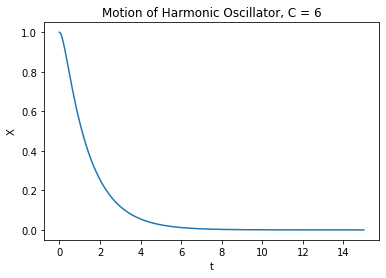

PART B


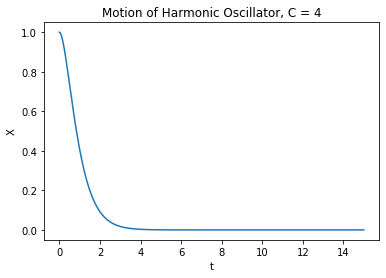

PART C


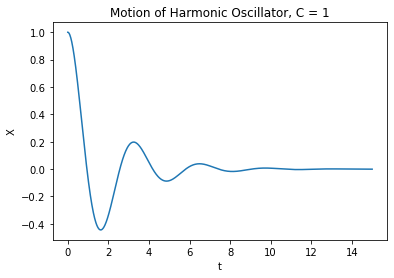

As you can see, when C = 6 and when C = 4, the friction overwhelms the oscillatory behavior so severely that you do not even see oscillation, whereas when C = 1, you can clearly see the oscillatory behavior despite the damping from friction. This is in accordance with my intution, since a lower coefficient of friction would mean less damping of the oscillation, which is exactly what I am seeing in these plots!


In [9]:
print("PART A")
# create t interval
tmin = 0 
tmax = 15
Nt = 1000
t = np.linspace(tmin,tmax,Nt)

# initial conditions: 
uf0 = 1 
vf0 = 0 

# define constants
m = 1 # mass 
k = 4 # spring constant
c = 6 # set c = 6 for this part 

# def gf and ff which are needed for RK method

def gf(t,uf,ud):
    return ((-c*ud)-(k*uf))/m

def ff(t,uf,ud):
    return ud

# get x array
x = ode2_rk2(Nt, tmin, tmax, uf0, vf0)
plt.plot(t,x)
plt.title("Motion of Harmonic Oscillator, C = 6")
plt.xlabel("t")
plt.ylabel("X")
plt.show()
print("PART B")
c = 4 # set c = 4 for this part 
def gf(t,uf,ud):
    return ((-c*ud)-(k*uf))/m

def ff(t,uf,ud):
    return ud
# get x array 
x = ode2_rk2(Nt, tmin, tmax, uf0, vf0)
plt.plot(t,x)
plt.title("Motion of Harmonic Oscillator, C = 4")
plt.xlabel("t")
plt.ylabel("X")
plt.show()
print("PART C")
c = 1 # set c = 1 for this part 
def gf(t,uf,ud):
    return ((-c*ud)-(k*uf))/m

def ff(t,uf,ud):
    return ud
x = ode2_rk2(Nt, tmin, tmax, uf0, vf0)
plt.plot(t,x)
plt.title("Motion of Harmonic Oscillator, C = 1")
plt.xlabel("t")
plt.ylabel("X")
plt.show()
print("As you can see, when C = 6 and when C = 4, the friction overwhelms the oscillatory behavior so severely that you do not even see oscillation, whereas when C = 1, you can clearly see the oscillatory behavior despite the damping from friction. This is in accordance with my intution, since a lower coefficient of friction would mean less damping of the oscillation, which is exactly what I am seeing in these plots!")